In [1]:
import numpy as np
import pandas as pd

train_df=pd.read_csv('datasets/playground-series-s5e7/train.csv')
test_df=pd.read_csv('datasets/playground-series-s5e7/test.csv')

In [2]:
# train_df.info()
# train_df.head()
# train_df.describe()
# train_df.isnull().sum()

In [3]:
def rename_dataset(df):
    df=df.rename(columns={
        'Time_spent_Alone': 'TimeSpentAlone',
        'Stage_fear': 'StageFear',
        'Social_event_attendance': 'SocialEventAttendance',
        'Going_outside': 'GoingOutside',
        'Drained_after_socializing': 'DrainedAfterSocializing',
        'Friends_circle_size': 'FriendsCircleSize',
        'Post_frequency': 'PostFrequency'
    })

    return df
    
train_df=rename_dataset(train_df)
test_df=rename_dataset(test_df)

train_df=train_df.drop(columns=['id'])

In [4]:
# check for skewness to decide whether to use mean or median for filling NaN values
print(train_df[['TimeSpentAlone', 'SocialEventAttendance', 'GoingOutside', 
          'FriendsCircleSize', 'PostFrequency']].skew())

def preprocess_data(df):
    df['TimeSpentAlone']=df['TimeSpentAlone'].fillna(df['TimeSpentAlone'].median())
    df['StageFear']=df['StageFear'].fillna(df['StageFear'].mode()[0])
    df['SocialEventAttendance']=df['SocialEventAttendance'].fillna(df['SocialEventAttendance'].mean())
    df['GoingOutside']=df['GoingOutside'].fillna(df['GoingOutside'].mean())
    df['DrainedAfterSocializing']=df['DrainedAfterSocializing'].fillna(df['DrainedAfterSocializing'].mode()[0])
    df['FriendsCircleSize']=df['FriendsCircleSize'].fillna(df['FriendsCircleSize'].mean())
    df['PostFrequency']=df['PostFrequency'].fillna(df['PostFrequency'].mean())

    df['StageFear']=df['StageFear'].map({'No': 0, 'Yes': 1})
    df['DrainedAfterSocializing']=df['DrainedAfterSocializing'].map({'No': 0, 'Yes': 1})
    
    df['ActivityScore'] = df['SocialEventAttendance'] + df['GoingOutside']
    return df
    
train_df=preprocess_data(train_df)
test_df=preprocess_data(test_df)

TimeSpentAlone           1.133777
SocialEventAttendance   -0.229238
GoingOutside            -0.367221
FriendsCircleSize       -0.051806
PostFrequency           -0.058706
dtype: float64


In [5]:
# from sklearn.model_selection import KFold

# train_df['Personality']=train_df['Personality'].map({'Extrovert': 0, 'Introvert': 1})

# def target_encode_column(df, target, column, n_splits=5):
#     df[column + '_TE'] = np.nan
#     kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

#     for train_idx, val_idx in kf.split(df):
#         train_fold = df.iloc[train_idx]
#         val_fold = df.iloc[val_idx]

#         encoding_map = train_fold.groupby(column)[target].mean()
#         df.loc[val_fold.index, column + '_TE'] = val_fold[column].map(encoding_map)

#     df[column + '_TE'] = df[column + '_TE'].fillna(df[target].mean())
#     return df
    
# train_df = target_encode_column(train_df, 'Personality', 'StageFear')
# train_df = target_encode_column(train_df, 'Personality', 'DrainedAfterSocializing')

# # Apply the target encoding mapping from train_df to test_df
# for col in ['StageFear', 'DrainedAfterSocializing']:
#     encoding_map = train_df.groupby(col)['Personality'].mean()
#     test_df[col + '_TE'] = test_df[col].map(encoding_map)
#     test_df[col + '_TE'].fillna(train_df['Personality'].mean(), inplace=True)

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

# for col in train_df.columns:
#     sns.histplot(train_df[col], kde=True)
#     plt.title(f'Histplot - {col}')
#     plt.show()

#     sns.boxplot(train_df[col])
#     plt.title(f'Boxplot - {col}')
#     plt.show()

In [7]:
# TimeSpentAlone - right-skewed, 3 max outliers
# StageFear - negatively-imbalanced (lots of No)
# DrainedAfterSocializing - negatively-imbalanced (lots of No)
# Personality - negatively-imbalanced (lots of Extroverts)

cols=['TimeSpentAlone', 'SocialEventAttendance', 'GoingOutside', 'FriendsCircleSize', 'PostFrequency']
# for col in cols:
#     # Outliers
#     Q1=train_df[col].quantile(.25)
#     Q3=train_df[col].quantile(.75)
#     IQR=Q3-Q1

#     lower_bound=Q1-1.5*IQR
#     upper_bound=Q3+1.5*IQR
    
#     print(f"Lower Bound[{col}]: {lower_bound}")
#     print(f"Upper Bound[{col}]: {upper_bound}")

#     # Distribution
#     print(train_df[col].skew())

# TimeSpentAlone - Right-skewed
train_df['TimeSpentAlone_log']=np.log1p(train_df['TimeSpentAlone'])
train_df=train_df.drop(columns=['TimeSpentAlone'])

test_df['TimeSpentAlone_log']=np.log1p(test_df['TimeSpentAlone'])
test_df=test_df.drop(columns=['TimeSpentAlone'])

# sns.histplot(train_df['TimeSpentAlone_log'], kde=True)
# plt.title(f'Histplot - TimeSpentAlone_log')
# plt.show()

print(f'Skewness Post-Log Transformation: {train_df['TimeSpentAlone_log'].skew()}')

Skewness Post-Log Transformation: -0.04231873091387832


In [8]:
# sns.barplot(data=train_df, x='DrainedAfterSocializing', y='TimeSpentAlone')
# plt.title('DrainedAfterSocializing vs. TimeSpentAlone')
# plt.xlabel('DrainedAfterSocializing')
# plt.ylabel('TimeSpentAlone')
# plt.tight_layout()
# plt.show()

# sns.countplot(data=train_df, x='StageFear', hue='Personality')
# plt.title('StageFear vs. Personality')
# plt.xlabel('StageFear')
# plt.ylabel('Count')
# plt.tight_layout()
# plt.show()

# sns.barplot(data=train_df, x='FriendsCircleSize', y='Personality')
# plt.title('FriendsCircleSize vs. Personality')
# plt.xlabel('FriendsCircleSize')
# plt.ylabel('Personality')
# plt.tight_layout()
# plt.show()

# sns.barplot(data=train_df, x='SocialEventAttendance', y='Personality')
# plt.title('SocialEventAttendance vs. Personality')
# plt.xlabel('SocialEventAttendance')
# plt.ylabel('Personality')
# plt.tight_layout()
# plt.show()

# sns.barplot(data=train_df, x='SocialEventAttendance', y='DrainedAfterSocializing')
# plt.title('SocialEventAttendance vs. DrainedAfterSocializing')
# plt.xlabel('SocialEventAttendance')
# plt.ylabel('DrainedAfterSocializing')
# plt.tight_layout()
# plt.show()

In [9]:
# corr = train_df.corr(numeric_only=True)

# plt.figure(figsize=(8, 6))
# sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
# plt.title('Feature Correlation Heatmap')
# plt.show()

In [10]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV

from sklearn.ensemble import RandomForestClassifier

X=train_df.drop(columns=['Personality'])
y=train_df['Personality']

X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.2, random_state=42)

model=RandomForestClassifier(
    bootstrap=True,
     max_depth=None,
     max_features='sqrt',
     min_samples_leaf=1,
     min_samples_split=10,
     n_estimators=300
)

# param_grid = {
#     'n_estimators': [100, 200, 300],                # Number of trees
#     'max_depth': [None, 10, 20, 30],                # Maximum depth of the tree
#     'min_samples_split': [2, 5, 10],                # Minimum samples required to split a node
#     'min_samples_leaf': [1, 2, 4],                  # Minimum samples required at each leaf node
#     'max_features': ['sqrt', 'log2', None],         # Number of features to consider at each split
#     'bootstrap': [True, False]                      # Whether bootstrap samples are used
# }

# grid_search=GridSearchCV(
#     estimator=model,
#     param_grid=param_grid,
#     cv=5,
#     scoring='accuracy',
#     n_jobs=-1,
#     verbose=2
#)

model.fit(X_train, y_train)
predictions=model.predict(X_test)
accuracy=accuracy_score(y_test, predictions)

[ ACCURACY ]


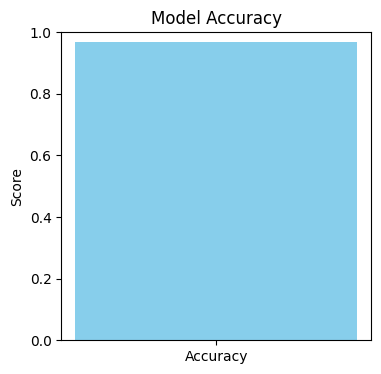

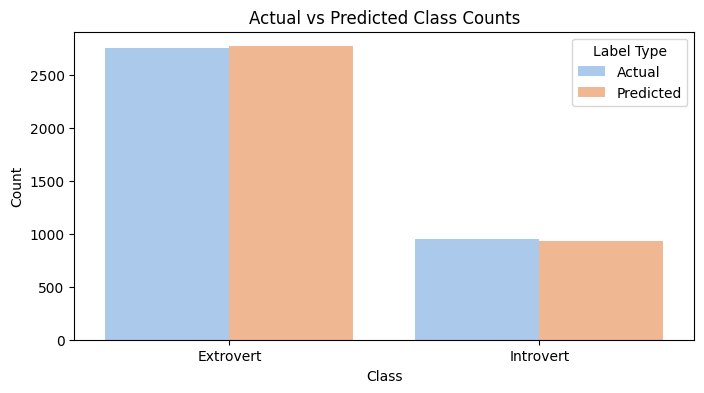

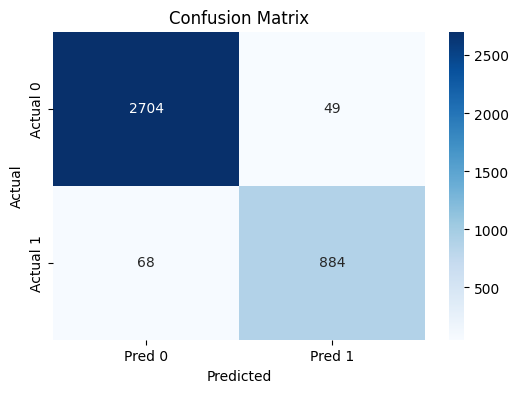

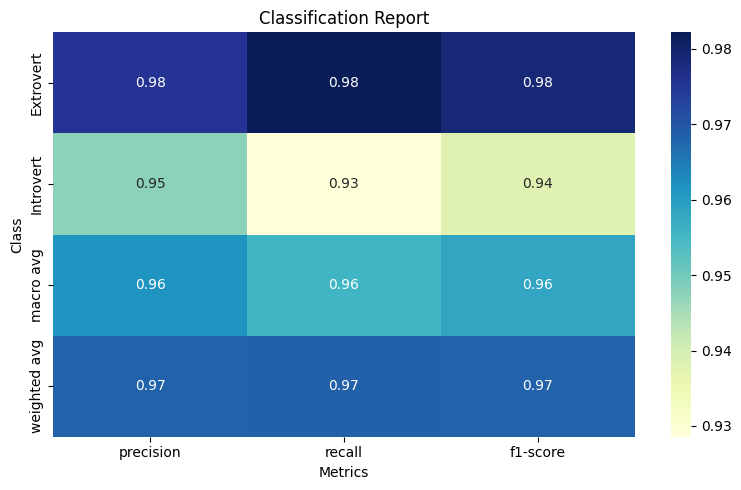

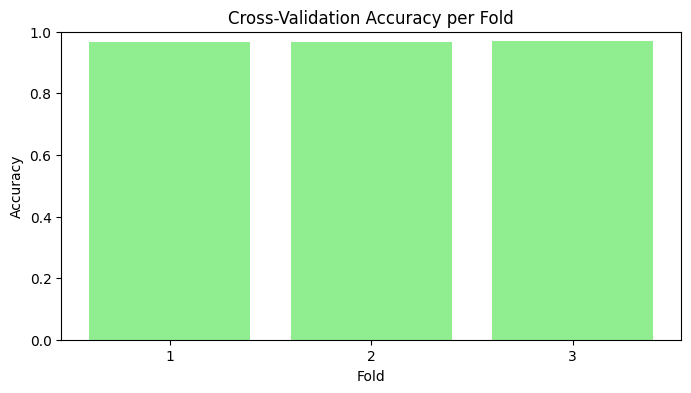

In [11]:
# 1. Accuracy - Bar Plot
print("[ ACCURACY ]")
plt.figure(figsize=(4, 4))
plt.bar(["Accuracy"], [accuracy], color='skyblue')
plt.ylim(0, 1)
plt.title("Model Accuracy")
plt.ylabel("Score")
plt.show()

# 2. Actual vs Predicted - Bar Chart
results_df = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': predictions
})

plt.figure(figsize=(8, 4))
sns.countplot(
    x='value', hue='Type',
    data=pd.melt(results_df, value_vars=['Actual', 'Predicted'], var_name='Type'),
    palette='pastel'
)
plt.title("Actual vs Predicted Class Counts")
plt.xlabel("Class")
plt.ylabel("Count")
plt.legend(title='Label Type')
plt.show()

# 3. Confusion Matrix - Heatmap
cm = confusion_matrix(y_test, predictions)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Pred 0', 'Pred 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# 4. Precision, Recall, F1 Score - Heatmap
report = classification_report(y_test, predictions, output_dict=True, zero_division=0)

# Convert to DataFrame (remove 'accuracy' to keep it 2D for heatmap)
report_df = pd.DataFrame(report).drop(columns=['accuracy'])
plt.figure(figsize=(8, 5))
sns.heatmap(report_df.iloc[:3, :].T, annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Classification Report")
plt.ylabel("Class")
plt.xlabel("Metrics")
plt.tight_layout()
plt.show()

# 5. Cross-Validation Scores - Bar Plot
scores = cross_val_score(model, X, y, cv=3)
plt.figure(figsize=(8, 4))
plt.bar(range(1, 4), scores, color='lightgreen')
plt.ylim(0, 1)
plt.title("Cross-Validation Accuracy per Fold")
plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.xticks(range(1, 4))
plt.show()

In [12]:
# Print the accuracy
print(f"Accuracy: {accuracy:.4f}")

# Check feature importance
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 10 Most Important Features:")
print(feature_importance.head(10))

# Check if any single feature can perfectly classify
print("\nChecking individual feature accuracy:")
for feature in X_train.columns:
    from sklearn.tree import DecisionTreeClassifier
    simple_model = DecisionTreeClassifier(max_depth=1)
    simple_model.fit(X_train[[feature]], y_train)
    simple_pred = simple_model.predict(X_test[[feature]])
    simple_acc = accuracy_score(y_test, simple_pred)
    print(f"{feature}: {simple_acc:.4f}")

Accuracy: 0.9684

Top 10 Most Important Features:
                   feature  importance
6            ActivityScore    0.273946
3  DrainedAfterSocializing    0.178466
0                StageFear    0.144715
7       TimeSpentAlone_log    0.142557
5            PostFrequency    0.098043
1    SocialEventAttendance    0.074556
2             GoingOutside    0.064050
4        FriendsCircleSize    0.023667

Checking individual feature accuracy:
StageFear: 0.9328
SocialEventAttendance: 0.9198
GoingOutside: 0.9215
DrainedAfterSocializing: 0.9363
FriendsCircleSize: 0.8691
PostFrequency: 0.9152
ActivityScore: 0.9460
TimeSpentAlone_log: 0.9233


In [13]:
import joblib

# Prepare test features
X_test_final = test_df.drop(columns=['id'])  # Ensure this matches your training columns

# Predict
test_predictions = model.predict(X_test_final)

# Map predictions back to original class labels
test_predictions_labels = pd.Series(test_predictions).map({0: 'Extrovert', 1: 'Introvert'})

# Create submission DataFrame
submission = pd.DataFrame({
    'id': test_df['id'],
    'Personality': test_predictions_labels
})

# Save to CSV
submission.to_csv('submission.csv', index=False)

# Save model (optional)
joblib.dump(model, 'PredictTheIntrovertsFromTheExtroverts[Personality].joblib')

['PredictTheIntrovertsFromTheExtroverts[Personality].joblib']